# TP - Mini Reseau de Neurones avec NumPy (XOR)

Partie A : fonctions d'activation + petit reseau XOR (2->3->1)

Partie B : dataset XOR bruite + evaluation du modele

## Partie A : Mini reseau de neurones pour XOR

### I. Mise en place

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# x sert juste a tracer les courbes des activations
x = np.linspace(-3, 3, 600)
print(x.shape)


(600,)


### I.2 - Fonctions d'activation + leurs derivees

La derivee est calculee a partir de z (pre-activation) ou de a (la sortie), ca depend de la fonction. Pour rester simple j'ai fait toutes les derivees avec la signature `d(z, a)`, meme si certaines n'utilisent que z et d'autres que a.

In [2]:
def relu(z):
    return np.maximum(0, z)

def d_relu(z, a):
    return (z > 0).astype(float)

def sigmoid(z):
    # version simple, peut faire un overflow si z tres negatif
    return 1 / (1 + np.exp(-z))

def sigmoid_stable(z):
    # version qui evite l'overflow
    return np.where(z >= 0, 1/(1+np.exp(-z)), np.exp(z)/(1+np.exp(z)))

def d_sigmoid_stable(z, a):
    # a = sigmoid_stable(z)
    return a * (1 - a)

def tanh_act(z):
    return np.tanh(z)

def d_tanh(z, a):
    # a = tanh(z)
    return 1 - a**2

def leaky_relu(z, alpha=0.1):
    return np.where(z > 0, z, alpha * z)

def d_leaky_relu(z, a, alpha=0.1):
    return np.where(z > 0, 1.0, alpha)

activations = {
    "Relu": relu,
    "Sigmoid": sigmoid,
    "Sigmoid_stable": sigmoid_stable,
    "Tanh": tanh_act,
    "LeakyRelu": leaky_relu,
}

d_activations = {
    "Relu": d_relu,
    "Sigmoid": d_sigmoid_stable,       # on derive la version stable, la normale c'est pareil
    "Sigmoid_stable": d_sigmoid_stable,
    "Tanh": d_tanh,
    "LeakyRelu": d_leaky_relu,
}


### I.4 - Couleurs et marqueurs pour les courbes

In [3]:
couleurs = {
    "Relu": "tab:blue",
    "Sigmoid": "tab:green",
    "Sigmoid_stable": "tab:purple",
    "Tanh": "tab:red",
    "LeakyRelu": "tab:orange",
}

markers = {
    "Relu": "o",
    "Sigmoid": "s",
    "Sigmoid_stable": "^",
    "Tanh": "v",
    "LeakyRelu": "D",
}


## II. Trace comparatif sur une seule figure

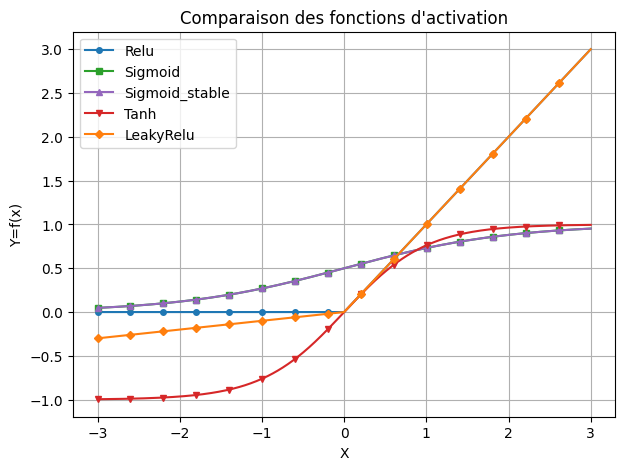

In [4]:
plt.figure(figsize=(7, 5))
for nom in activations:
    y_act = activations[nom](x)
    plt.plot(x, y_act, label=nom, color=couleurs[nom],
             marker=markers[nom], markersize=4, markevery=40)

plt.title("Comparaison des fonctions d'activation")
plt.xlabel("X")
plt.ylabel("Y=f(x)")
plt.grid(True)
plt.legend()
plt.show()


## III. Grille 2x2 (une fonction par sous-figure)

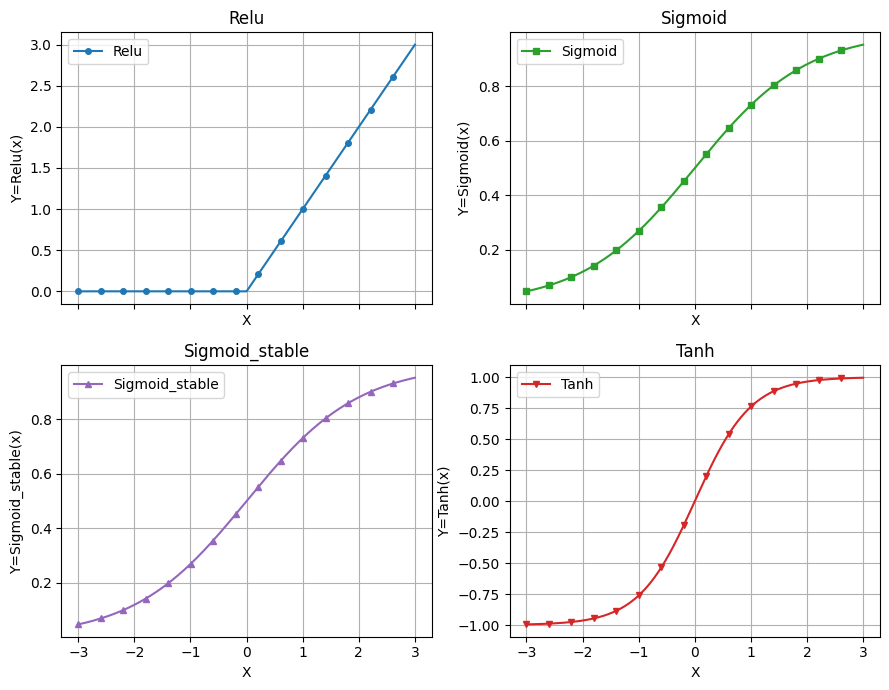

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharex=True)
axes = axes.ravel()

noms_4 = ["Relu", "Sigmoid", "Sigmoid_stable", "Tanh"]
for ax, nom in zip(axes, noms_4):
    y_act = activations[nom](x)
    ax.plot(x, y_act, label=nom, color=couleurs[nom],
            marker=markers[nom], markersize=4, markevery=40)
    ax.set_title(nom)
    ax.set_xlabel("X")
    ax.set_ylabel(f"Y={nom}(x)")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()


## IV. Extension 1 - on ajoute Softplus et ELU

In [6]:
def softplus(z):
    return np.log(1 + np.exp(z))

def d_softplus(z, a):
    return sigmoid_stable(z)

def elu(z, alpha=1.0):
    return np.where(z > 0, z, alpha * (np.exp(z) - 1))

def d_elu(z, a, alpha=1.0):
    return np.where(z > 0, 1.0, a + alpha)

activations["Softplus"] = softplus
activations["ELU"] = elu

d_activations["Softplus"] = d_softplus
d_activations["ELU"] = d_elu

couleurs["Softplus"] = "tab:cyan"
couleurs["ELU"] = "tab:pink"

markers["Softplus"] = "x"
markers["ELU"] = "*"


### IV.2 - Trace comparatif des 6 courbes

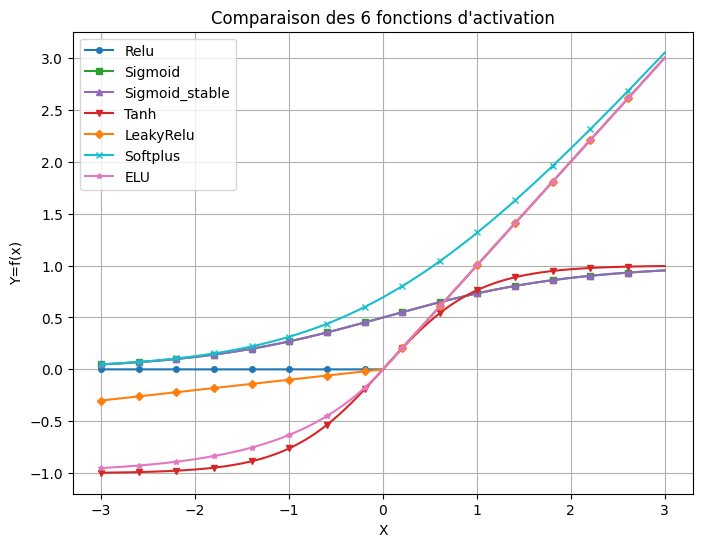

In [7]:
plt.figure(figsize=(8, 6))
for nom in activations:
    y_act = activations[nom](x)
    plt.plot(x, y_act, label=nom, color=couleurs[nom],
             marker=markers[nom], markersize=4, markevery=40)

plt.title("Comparaison des 6 fonctions d'activation")
plt.xlabel("X")
plt.ylabel("Y=f(x)")
plt.grid(True)
plt.legend()
plt.show()


### IV.3 - Chaque courbe sur sa sous-figure (grille 3x2)

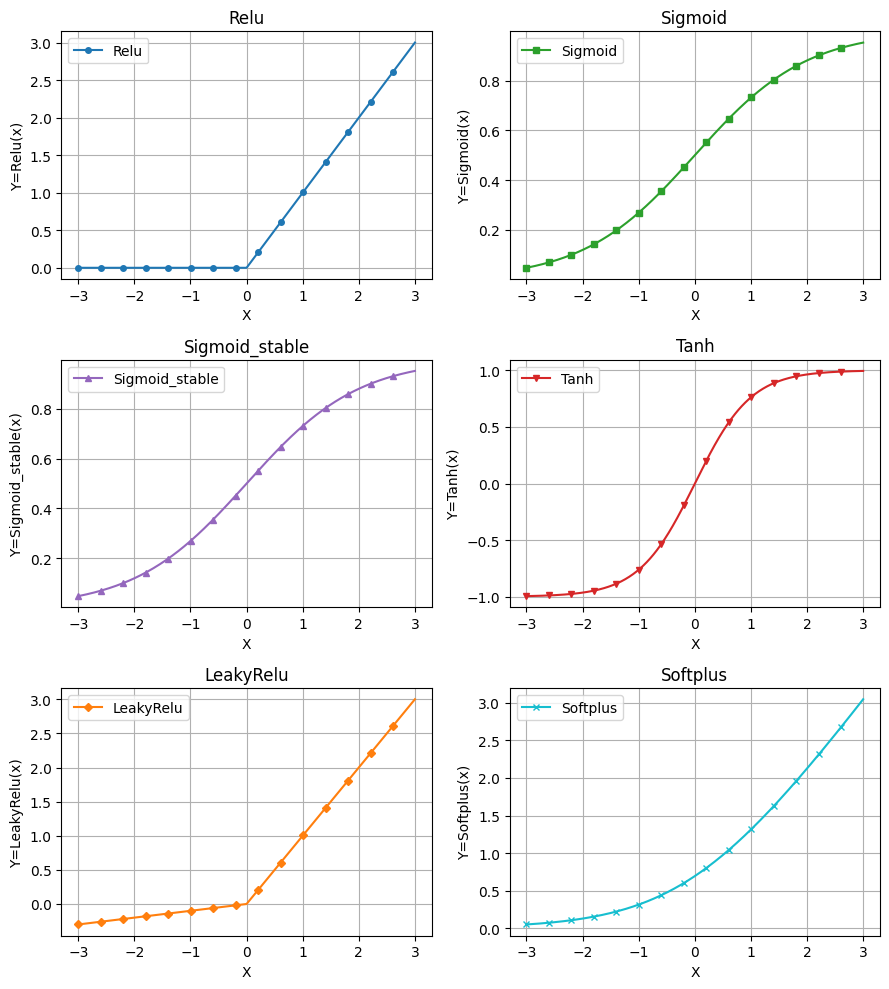

In [8]:
def sub_tracer(rows, cols):
    fig, axes = plt.subplots(rows, cols, figsize=(9, 10))
    axes = axes.ravel()
    for ax, nom in zip(axes, activations):
        y_act = activations[nom](x)
        ax.plot(x, y_act, label=nom, color=couleurs[nom],
                marker=markers[nom], markersize=4, markevery=40)
        ax.set_title(nom)
        ax.set_xlabel("X")
        ax.set_ylabel(f"Y={nom}(x)")
        ax.grid(True)
        ax.legend()
    plt.tight_layout()
    plt.show()

sub_tracer(3, 2)


## V. Extension 2 - Mini reseau de neurones (2 -> 3 -> 1) pour apprendre XOR

### V.2 - Dataset XOR

In [9]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([[0], [1], [1], [0]], dtype=float)

print(X_xor.shape)
print(y_xor.shape)


(4, 2)
(4, 1)


### V.3 - Visualisation des points

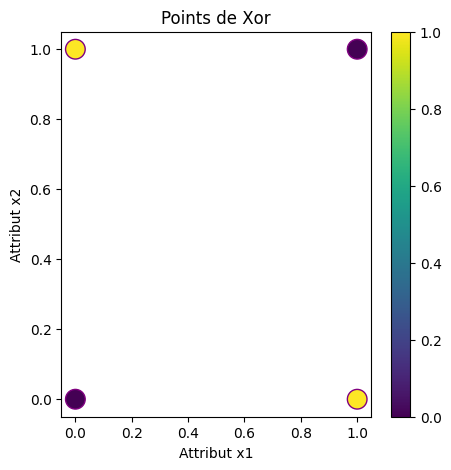

In [10]:
plt.figure(figsize=(5, 5))
plt.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor.ravel(), cmap="viridis",
            s=200, edgecolors="purple")
plt.xlabel("Attribut x1")
plt.ylabel("Attribut x2")
plt.title("Points de Xor")
plt.colorbar()
plt.show()


### V.4 - Initialisation des parametres W1, b1, W2, b2

In [11]:
np.random.seed(0)

input_dim, hidden_dim, output_dim = 2, 3, 1

W1 = np.random.randn(input_dim, hidden_dim) * 0.5
b1 = np.zeros((1, hidden_dim))
W2 = np.random.randn(hidden_dim, output_dim) * 0.5
b2 = np.zeros((1, output_dim))

print("W1.shape :", W1.shape, "  b1.shape :", b1.shape)
print("W2.shape :", W2.shape, "  b2.shape :", b2.shape)
print("W1 =", W1)
print("b1 =", b1)
print("W2 =", W2)
print("b2 =", b2)


W1.shape : (2, 3)   b1.shape : (1, 3)
W2.shape : (3, 1)   b2.shape : (1, 1)
W1 = [[ 0.88202617  0.2000786   0.48936899]
 [ 1.1204466   0.933779   -0.48863894]]
b1 = [[0. 0. 0.]]
W2 = [[ 0.47504421]
 [-0.0756786 ]
 [-0.05160943]]
b2 = [[0.]]


### V.5 - Choix des activations

Couche cachee = tanh, couche de sortie = sigmoid (classification binaire)

In [12]:
act_hid = tanh_act
act_out = sigmoid_stable

d_act_hid = d_tanh
d_act_out = d_sigmoid_stable


### V.6 - Propagation avant (forward)

In [13]:
def forward(X, W1, b1, W2, b2, act_hid, act_out):
    Z1 = X @ W1 + b1
    A1 = act_hid(Z1)
    Z2 = A1 @ W2 + b2
    y_hat = act_out(Z2)
    cache = (X, Z1, A1, Z2, y_hat)
    return y_hat, cache


y_hat, cache = forward(X_xor, W1, b1, W2, b2, act_hid, act_out)
print("y_hat:\n", y_hat)
print("y_hat shape:", y_hat.shape)


y_hat:
 [[0.5       ]
 [0.58702188]
 [0.57388093]
 [0.59785233]]
y_hat shape: (4, 1)


### V.7 - Fonction de perte (MSE)

In [14]:
def mse(y_hat, y):
    return np.mean((y_hat - y) ** 2)


print("Loss:", mse(y_hat, y_xor))


Loss: 0.23988895051788972


### V.8 / V.9 - Backpropagation + boucle d'entrainement

J'ai garde les derivees generiques (d_act_hid, d_act_out) au lieu de les ecrire en dur, comme ca on peut changer l'activation plus tard pour l'etude d'influence (partie VI).

In [15]:
def train(X, y, W1, b1, W2, b2, lr=0.8, epochs=2000,
          f_act_hid=act_hid, f_act_out=act_out,
          f_d_act_hid=d_act_hid, f_d_act_out=d_act_out,
          verbose=True):
    losses = []

    for epoch in range(epochs):
        # ---------- Forward ----------
        y_hat, (Xc, Z1, A1, Z2, yhc) = forward(X, W1, b1, W2, b2, f_act_hid, f_act_out)

        # ---------- Loss ----------
        L = mse(y_hat, y)
        losses.append(L)

        # ---------- Backprop ----------
        N = y.shape[0]

        # dL/dy_hat  (derivee de la MSE)
        dY = 2 * (y_hat - y) / N

        # dZ2 = dY * sigma'(Z2)
        dZ2 = dY * f_d_act_out(Z2, y_hat)

        # dW2, db2  (Z2 = A1 W2 + b2)
        dW2 = A1.T @ dZ2
        db2 = np.sum(dZ2, axis=0)

        # on propage vers la couche cachee
        dA1 = dZ2 @ W2.T
        dZ1 = dA1 * f_d_act_hid(Z1, A1)

        # dW1, db1  (Z1 = X W1 + b1)
        dW1 = X.T @ dZ1
        db1 = np.sum(dZ1, axis=0)

        # ---------- Update (descente de gradient) ----------
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

        if verbose and epoch % 400 == 0:
            print(f"epoch={epoch:4d}  loss={L:.6f}")

    return W1, b1, W2, b2, losses


W1t, b1t, W2t, b2t, losses = train(X_xor, y_xor, W1, b1, W2, b2, lr=0.8, epochs=4000)
y_pred, _ = forward(X_xor, W1t, b1t, W2t, b2t, act_hid, act_out)
print("Probas:\n", y_pred)
print("Classes:\n", (y_pred >= 0.5).astype(int))


epoch=   0  loss=0.239889
epoch= 400  loss=0.004540
epoch= 800  loss=0.001587
epoch=1200  loss=0.000936


epoch=1600  loss=0.000658
epoch=2000  loss=0.000505
epoch=2400  loss=0.000409


epoch=2800  loss=0.000343

epoch=3200  loss=0.000295
epoch=3600  loss=0.000259
Probas:
 [[0.00579629]
 [0.98380831]
 [0.98364148]
 [0.01895762]]
Classes:
 [[0]
 [1]
 [1]
 [0]]


### V.10 - Courbe de convergence de la loss

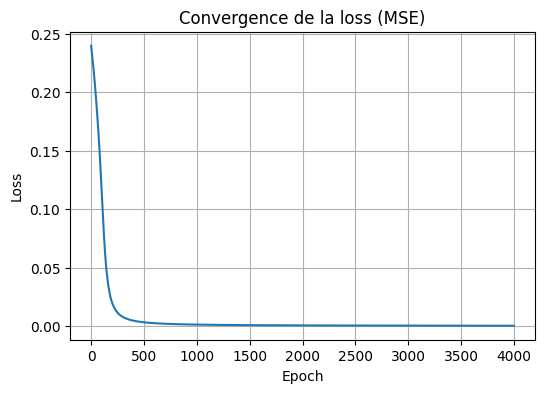

In [16]:
plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.title("Convergence de la loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


## VI. Etude de l'influence du learning rate, du nb de neurones caches et de l'activation

On refait l'entrainement plusieurs fois sur le meme XOR avec des reglages differents, et on compare les courbes de loss.

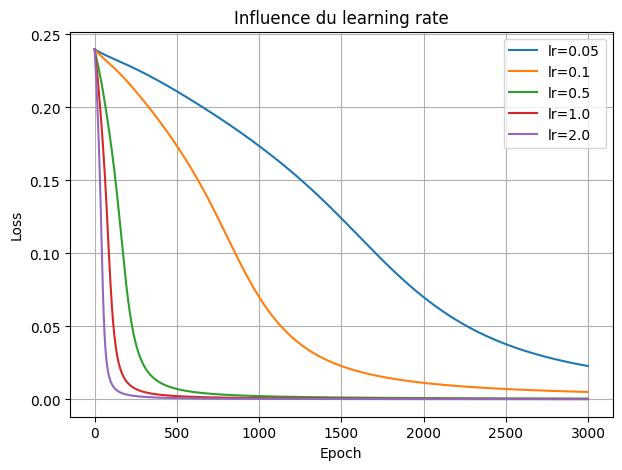

In [17]:
# --- Influence du learning rate ---
plt.figure(figsize=(7, 5))
for lr_test in [0.05, 0.1, 0.5, 1.0, 2.0]:
    np.random.seed(0)
    W1i = np.random.randn(2, 3) * 0.5
    b1i = np.zeros((1, 3))
    W2i = np.random.randn(3, 1) * 0.5
    b2i = np.zeros((1, 1))

    *_, losses_lr = train(X_xor, y_xor, W1i, b1i, W2i, b2i, lr=lr_test, epochs=3000, verbose=False)
    plt.plot(losses_lr, label=f"lr={lr_test}")

plt.title("Influence du learning rate")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


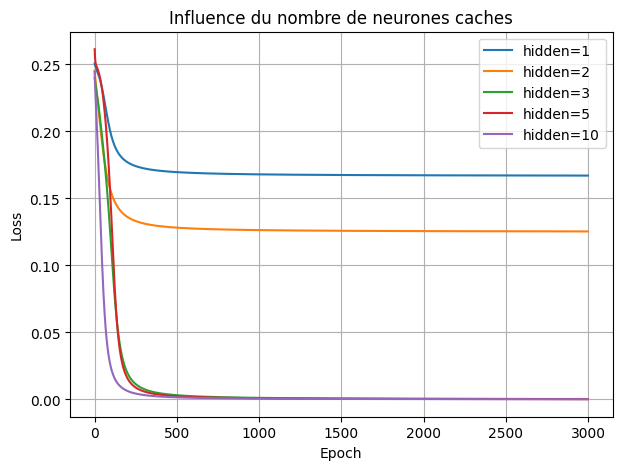

In [18]:
# --- Influence du nombre de neurones caches ---
plt.figure(figsize=(7, 5))
for h in [1, 2, 3, 5, 10]:
    np.random.seed(0)
    W1i = np.random.randn(2, h) * 0.5
    b1i = np.zeros((1, h))
    W2i = np.random.randn(h, 1) * 0.5
    b2i = np.zeros((1, 1))

    *_, losses_h = train(X_xor, y_xor, W1i, b1i, W2i, b2i, lr=0.8, epochs=3000, verbose=False)
    plt.plot(losses_h, label=f"hidden={h}")

plt.title("Influence du nombre de neurones caches")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


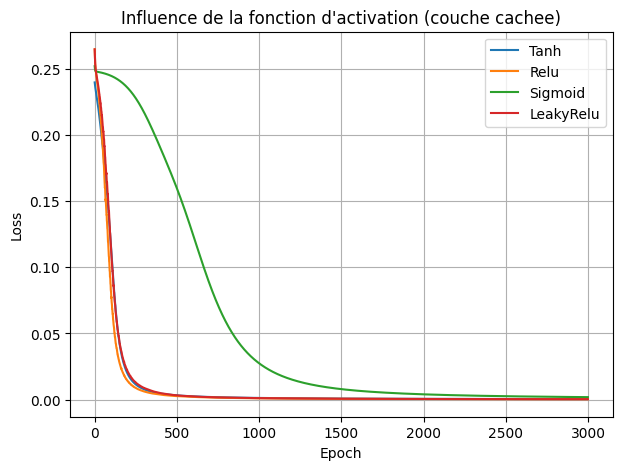

In [19]:
# --- Influence de la fonction d'activation cachee ---
plt.figure(figsize=(7, 5))
acts_a_tester = {
    "Tanh": (tanh_act, d_tanh),
    "Relu": (relu, d_relu),
    "Sigmoid": (sigmoid_stable, d_sigmoid_stable),
    "LeakyRelu": (leaky_relu, d_leaky_relu),
}

for nom, (f_act, f_d_act) in acts_a_tester.items():
    np.random.seed(0)
    W1i = np.random.randn(2, 3) * 0.5
    b1i = np.zeros((1, 3))
    W2i = np.random.randn(3, 1) * 0.5
    b2i = np.zeros((1, 1))

    *_, losses_act = train(X_xor, y_xor, W1i, b1i, W2i, b2i, lr=0.8, epochs=3000,
                            f_act_hid=f_act, f_d_act_hid=f_d_act, verbose=False)
    plt.plot(losses_act, label=nom)

plt.title("Influence de la fonction d'activation (couche cachee)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


## Partie B - Dataset XOR bruite + evaluation du modele

### I. Generation d'un dataset XOR bruite

In [20]:
def make_noisy_xor(n=10, noise=0.08, flip=0.05, seed=0):
    rng = np.random.default_rng(seed)

    # points XOR de base
    coins = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
    labels = np.array([[0], [1], [1], [0]], dtype=float)

    # duplication des points
    x = np.repeat(coins, n, axis=0)
    y = np.repeat(labels, n, axis=0)

    # ajout de bruit gaussien
    x = x + rng.normal(0, noise, x.shape)

    # on inverse une fraction des labels au hasard
    mask = rng.random(len(y)) < flip
    y[mask] = 1 - y[mask]

    return x, y


X, y = make_noisy_xor(n=100, noise=0.05, flip=0.04)
print(X.shape)
print(np.hstack([X, y])[:10])


(400, 2)
[[ 0.00628651 -0.00660524  0.        ]
 [ 0.03202113  0.00524501  0.        ]
 [-0.02678347  0.01807975  0.        ]
 [ 0.0652      0.04735405  0.        ]
 [-0.03518676 -0.06327107  0.        ]
 [-0.03116372  0.0020663   0.        ]
 [-0.11625154 -0.01093958  0.        ]
 [-0.06229555 -0.03661337  0.        ]
 [-0.02721295 -0.01581501  0.        ]
 [ 0.02058153  0.05212567  0.        ]]


### II. Separation train / test

In [21]:
def split_dataset(X, y, test_ratio=0.2, seed=0):
    rng = np.random.default_rng(seed)
    N = len(X)

    indices = np.arange(N)
    rng.shuffle(indices)

    cut = int((1 - test_ratio) * N)
    train_idx = indices[:cut]
    test_idx = indices[cut:]

    X_train = X[train_idx]
    X_test = X[test_idx]
    y_train = y[train_idx]
    y_test = y[test_idx]

    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = split_dataset(X, y)

print("Train size :", X_train.shape)
print("Test size :", X_test.shape)


Train size : (320, 2)
Test size : (80, 2)


### III. Entrainement du modele sur le dataset bruite

In [22]:
np.random.seed(1)
W1 = np.random.randn(2, 3) * 0.5
b1 = np.zeros((1, 3))
W2 = np.random.randn(3, 1) * 0.5
b2 = np.zeros((1, 1))

W1, b1, W2, b2, losses = train(X_train, y_train, W1, b1, W2, b2, lr=0.5, epochs=20000)


epoch=   0  loss=0.267097
epoch= 400  loss=0.055570
epoch= 800  loss=0.040705


epoch=1200  loss=0.039438


epoch=1600  loss=0.039039
epoch=2000  loss=0.038849
epoch=2400  loss=0.038736


epoch=2800  loss=0.038660
epoch=3200  loss=0.038605
epoch=3600  loss=0.038562
epoch=4000  loss=0.038528


epoch=4400  loss=0.038499
epoch=4800  loss=0.038476
epoch=5200  loss=0.038456


...

epoch=13200  loss=0.038299
epoch=13600  loss=0.038296
epoch=14000  loss=0.038292
epoch=14400  loss=0.038289


epoch=14800  loss=0.038286
epoch=15200  loss=0.038283
epoch=15600  loss=0.038280


epoch=16000  loss=0.038277
epoch=16400  loss=0.038274
epoch=16800  loss=0.038271
epoch=17200  loss=0.038269


epoch=17600  loss=0.038266
epoch=18000  loss=0.038263
epoch=18400  loss=0.038261


epoch=18800  loss=0.038259
epoch=19200  loss=0.038256
epoch=19600  loss=0.038254


### Predictions sur le test set

In [23]:
y_score, _ = forward(X_test, W1, b1, W2, b2, act_hid, act_out)

threshold = 0.5
y_pred_test = (y_score >= threshold).astype(int)

print("Classes:\n", y_pred_test[:5, :])


Classes:
 [[0]
 [1]
 [0]
 [1]
 [1]]


## IV. Matrice de confusion : TP, TN, FP, FN

In [24]:
def confusion_matrix(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    return TP, TN, FP, FN


TP, TN, FP, FN = confusion_matrix(y_test, y_pred_test)
print("TP :", TP)
print("TN :", TN)
print("FP :", FP)
print("FN :", FN)


TP : 32
TN : 43
FP : 3
FN : 2


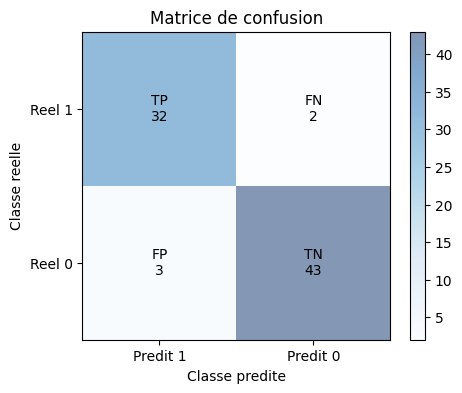

In [25]:
cm = np.array([[TP, FN],
               [FP, TN]])

cm_txt = np.array([[f"TP\n{TP}", f"FN\n{FN}"],
                    [f"FP\n{FP}", f"TN\n{TN}"]])

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues", alpha=0.5)
plt.title("Matrice de confusion")
plt.colorbar()

plt.xticks([0, 1], ["Predit 1", "Predit 0"])
plt.yticks([0, 1], ["Reel 1", "Reel 0"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm_txt[i, j], ha="center", va="center")

plt.xlabel("Classe predite")
plt.ylabel("Classe reelle")
plt.show()


## V. Metriques de classification (accuracy, precision, recall, F1)

In [26]:
def classification_metrics(TP, TN, FP, FN):
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return accuracy, precision, recall, f1


accuracy, precision, recall, f1 = classification_metrics(TP, TN, FP, FN)

print("Accuracy  :", accuracy)
print("Precision :", precision)
print("Recall    :", recall)
print("F1        :", f1)


Accuracy  : 0.9375
Precision : 0.9142857142857143
Recall    : 0.9411764705882353
F1        : 0.9275362318840579


## VI. Courbe ROC + AUC

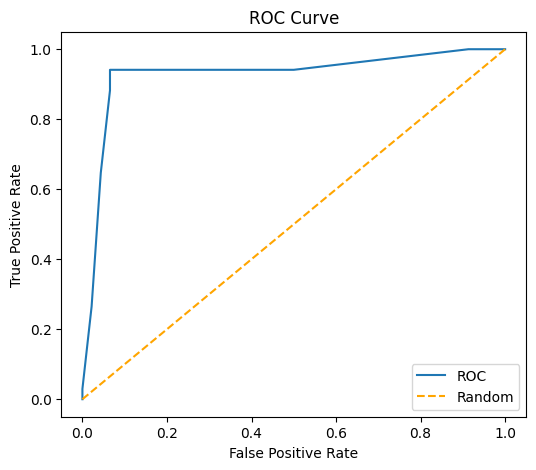

In [27]:
def roc_curve(y_true, y_score):
    thresholds = np.linspace(1, 0, 200)
    TPR = []
    FPR = []

    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        TP, TN, FP, FN = confusion_matrix(y_true, y_pred)
        TPR.append(TP / (TP + FN) if (TP + FN) > 0 else 0.0)
        FPR.append(FP / (FP + TN) if (FP + TN) > 0 else 0.0)

    return np.array(FPR), np.array(TPR)


FPR, TPR = roc_curve(y_test, y_score)

plt.figure(figsize=(6, 5))
plt.plot(FPR, TPR, label="ROC")
plt.plot([0, 1], [0, 1], linestyle="--", color="orange", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [28]:
import scipy.integrate as integr

auc = integr.trapezoid(TPR, FPR)
print("AUC =", auc)


AUC = 0.9267902813299234
